In [1]:
from richards_model import RichardsSolver
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as mPolygon
from matplotlib.collections import PatchCollection

In [2]:
def run_mass_balance_check(solver, h_init, dt, steps):
    h_current = h_init.copy()
    cumulative_error = 0
    
    print(f"{'Step':<8} | {'Error (m3)':<15} | {'Rel. Error (%)':<15}")
    print("-" * 45)

    for t in range(steps):
        # 1. Measure storage before step
        s_old = solver.calculate_storage(h_current)
        
        # 2. Step the solver
        h_next = solver.solve_step(h_current, dt)
        
        # 3. Measure storage after step
        s_new = solver.calculate_storage(h_next)
        
        # 4. Measure Flux during step
        net_flux = solver.get_boundary_flux_with_rain(h_next)
        
        # 5. Calculate Mass Balance Error
        # Expected Change = flux * dt
        actual_change = s_new - s_old
        expected_change = net_flux * dt
        
        step_error = actual_change - expected_change
        cumulative_error += step_error
        
        rel_error = (step_error / s_new) * 100 if s_new != 0 else 0
        
        if t % 5 == 0: # Print every 5 steps
            print(f"{t:<8} | {step_error:<15.6e} | {rel_error:<15.6e}")
        
        h_current = h_next

    print("-" * 45)
    print(f"Total Cumulative Mass Error: {cumulative_error:.6e} m3")

# Usage for Experiment 1 (Regular)
# run_mass_balance_check(regular_solver, h_start, 60, 50)

# Usage for Experiment 2 (Unstructured)
# run_mass_balance_check(unstructured_solver, h_start, 60, 50)

In [3]:
def run_simulation_with_diagnostics(solver, h_init, dt, steps):
    h_current = h_init.copy()
    
    # Storage lists for plotting
    times = []
    errors = []
    cumulative_errors = []
    total_error = 0
    
    for t in range(steps):
        s_old = solver.calculate_storage(h_current)
        h_next = solver.solve_step(h_current, dt)
        s_new = solver.calculate_storage(h_next)
        
        # Boundary flux calculation
        net_flux = solver.get_boundary_flux_with_rain(h_next)
        
        # Mass Balance Calculation
        actual_change = s_new - s_old
        expected_change = net_flux * dt
        step_error = actual_change - expected_change
        
        total_error += step_error
        
        # Append to lists
        times.append(t * dt)
        errors.append(step_error)
        cumulative_errors.append(total_error)
        
        h_current = h_next
        
    return times, errors, cumulative_errors

# Execute for both experiments
# t1, err1, cum1 = run_simulation_with_diagnostics(regular_solver, ...)
# t2, err2, cum2 = run_simulation_with_diagnostics(unstructured_solver, ...)

In [4]:
def plot_mass_diagnostics(times, step_errors, cum_errors, title="Mass Balance Diagnostics"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    
    # Plot 1: Instantaneous Step Error
    ax1.plot(times, step_errors, color='navy', alpha=0.6, label='Step Error')
    ax1.tick_params(axis='both', which='major', labelsize=15)
    ax1.tick_params(axis='both', which='minor', labelsize=15)
    ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax1.set_ylabel("Step Error ($m^3$)",fontsize=15)
    #ax1.set_title(f"{title}: Step-wise Accuracy", fontsize=15)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Cumulative Error
    ax2.plot(times, cum_errors, color='maroon', linewidth=2, label='Cumulative Error')
    ax2.tick_params(axis='both', which='major', labelsize=15)
    ax2.tick_params(axis='both', which='minor', labelsize=15)
    ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax2.set_ylabel("Cumulative Error ($m^3$)",fontsize=15)
    ax2.set_xlabel("Time (s)",fontsize=15)
    #ax2.set_title("Long-term Mass Drift",fontsize=15)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# plot_mass_diagnostics(t1, err1, cum1, title="Regular Grid Experiment")
# plot_mass_diagnostics(t2, err2, cum2, title="Unstructured Grid Experiment")

# Example 3D Regular Grid

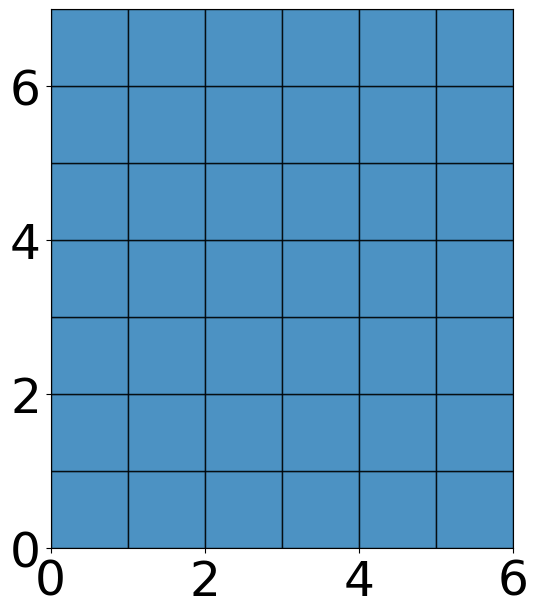

In [5]:
fig, ax = plt.subplots(figsize=(6,7))
ax.set_xlim(0, 6)
ax.set_ylim(0, 7)

patches = []

# Create a 6×7 grid of 1×1 squares
for x in range(6):
    for y in range(7):
        # base square
        square = np.array([[0,0], [1,0], [1,1], [0,1]])
        # shift it to (x, y)
        square = square + np.array([x, y])
        patches.append(mPolygon(square, edgecolor='black'))

# Color each cell randomly
colors = np.random.rand(len(patches))
collection = PatchCollection(
    patches,
    #cmap='Spectral',
    alpha=0.8,
    match_original=True
)
#collection.set_array(colors)

ax.add_collection(collection)
ax.set_aspect('equal')  # ensures squares stay square
ax.tick_params(axis='both', which='major', labelsize=35)
#ax.tick_params(axis='both', which='minor', labelsize=35)
plt.show()


In [7]:
def generate_regular_grid(rows=7, cols=6):
    adj_prisms = {}
    A_ij = {}
    W_ij = np.zeros((rows * cols, rows * cols))
    L_ij = np.zeros((rows * cols, rows * cols))

    for r in range(rows):
        for c in range(cols):
            i = r * cols + c
            A_ij[i] = 0.04*0.04  # Area of 1x1 cell
            adj_prisms[i] = []

            # Check neighbors: Top, Bottom, Left, Right
            neighbors = [
                (r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)
            ]

            for nr, nc in neighbors:
                if 0 <= nr < rows and 0 <= nc < cols:
                    j = nr * cols + nc
                    adj_prisms[i].append(j)
                    W_ij[i][j] = 0.04  # Shared edge width
                    L_ij[i][j] = 0.04  # Distance between centers

    # Convert matrices to dictionaries to match your class structure
    W_dict = {i: list(row) for i, row in enumerate(W_ij)}
    L_dict = {i: list(row) for i, row in enumerate(L_ij)}

    return adj_prisms, A_ij, W_dict, L_dict

# Generate parameters
adj, areas, widths, lengths = generate_regular_grid(7, 6)

In [7]:
n_prisms = 42
n_layers = 5
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04]


In [8]:
# Initialize the solver with the new grid
reg_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.full((n_prisms,n_layers),100/100/3600),        # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = np.full((n_prisms),10.1),
    rainfall_intensity = 0.1/100/86400,
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths
)

In [9]:
# Setup initial state
h_old = np.full(reg_grid_solver.total_cells, -10.0)
dt = 864 #s

# 3. Run simulation
for t in range(150):
    h_new = reg_grid_solver.solve_step(h_old, dt)
    h_old = h_new
    print(f"Step {t} completed.")

Step 0 completed.
Step 1 completed.
Step 2 completed.
Step 3 completed.
Step 4 completed.
Step 5 completed.
Step 6 completed.
Step 7 completed.
Step 8 completed.
Step 9 completed.
Step 10 completed.
Step 11 completed.
Step 12 completed.
Step 13 completed.
Step 14 completed.
Step 15 completed.
Step 16 completed.
Step 17 completed.
Step 18 completed.
Step 19 completed.
Step 20 completed.
Step 21 completed.
Step 22 completed.
Step 23 completed.
Step 24 completed.
Step 25 completed.
Step 26 completed.
Step 27 completed.
Step 28 completed.
Step 29 completed.
Step 30 completed.
Step 31 completed.
Step 32 completed.
Step 33 completed.
Step 34 completed.
Step 35 completed.
Step 36 completed.
Step 37 completed.
Step 38 completed.
Step 39 completed.
Step 40 completed.
Step 41 completed.
Step 42 completed.
Step 43 completed.
Step 44 completed.
Step 45 completed.
Step 46 completed.
Step 47 completed.
Step 48 completed.
Step 49 completed.
Step 50 completed.
Step 51 completed.
Step 52 completed.
Ste

In [10]:
h_start = np.full(reg_grid_solver.total_cells, -10.0)
run_mass_balance_check(reg_grid_solver, h_start, 864, 150)

Step     | Error (m3)      | Rel. Error (%) 
---------------------------------------------
0        | -3.297605e-18   | -3.137010e-13  
5        | 1.117984e-15    | 1.060149e-10   
10       | 1.946777e-16    | 1.840204e-11   
15       | 4.917778e-17    | 4.633845e-12   
20       | 1.404963e-17    | 1.319668e-12   
25       | 2.990767e-18    | 2.800360e-13   
30       | -6.955199e-19   | -6.491972e-14  
35       | 8.223631e-19    | 7.651926e-14   
40       | 2.340246e-18    | 2.170766e-13   
45       | 5.376012e-18    | 4.971189e-13   
50       | -1.779722e-18   | -1.640609e-13  
55       | 3.424448e-18    | 3.147026e-13   
60       | -4.786795e-19   | -4.385464e-14  
65       | -6.955199e-19   | -6.352512e-14  
70       | -2.213403e-18   | -2.015420e-13  
75       | -2.430243e-18   | -2.206116e-13  
80       | 1.039204e-18    | 9.404950e-14   
85       | -1.779722e-18   | -1.605793e-13  
90       | 1.718418e-19    | 1.545793e-14   
95       | -4.815488e-18   | -4.318692e-13  
100      

In [11]:
h_start = np.full(reg_grid_solver.total_cells, -10.0)
t1, err1, cum1 = run_simulation_with_diagnostics(reg_grid_solver, h_start, 864, 150)

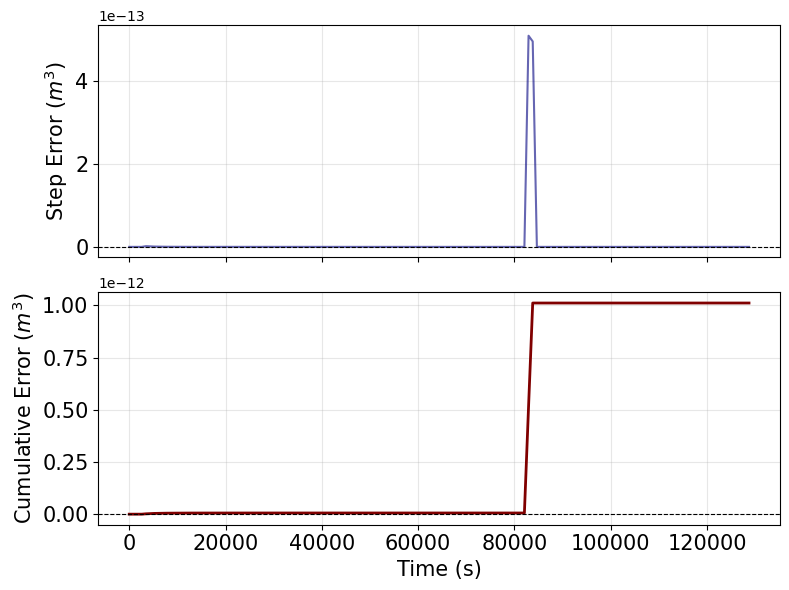

In [12]:
plot_mass_diagnostics(t1, err1, cum1, title="Regular Grid Experiment")

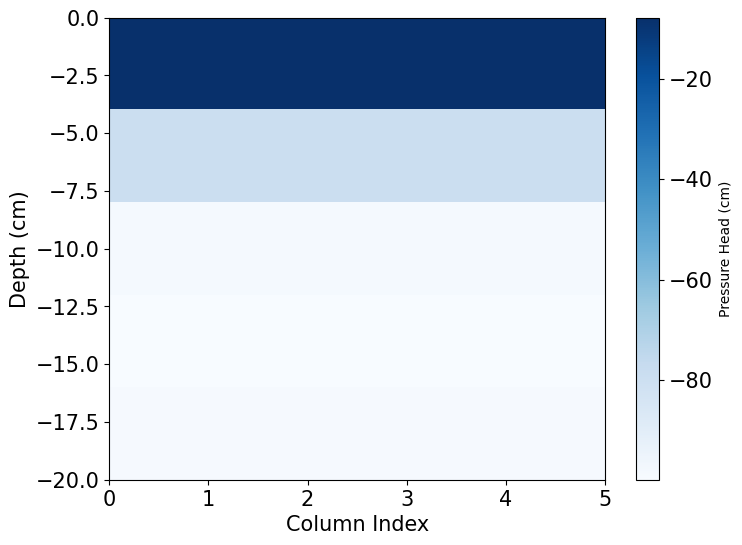

In [13]:
def plot_vertical_slice(h_new, row_to_slice, n_layers, dz, rows=7, cols=6):
    # 1. Reshape h_new to (Layers, Rows, Columns)
    # The solver has n_layers and n_prisms (which is rows * cols)
    h_reshaped = h_new.reshape((n_layers, rows, cols))
    
    # 2. Extract the slice along a specific row (East-West slice)
    # This gives us a 2D array of (Layers, Columns)
    slice_data = h_reshaped[:, row_to_slice, :]
    
    # 3. Create coordinates for the plot
    # x = column index, y = cumulative depth (negative dz)
    x = np.arange(cols)
    y = np.cumsum(dz[::-1])[::-1] # Approximate depths from dz
    
    plt.figure(figsize=(8, 6))
    im = plt.imshow(np.flipud(slice_data)*10, aspect='auto', cmap='Blues', 
                    extent=[0, cols-1, -sum(dz*100), 0])
    
    cbar = plt.colorbar(im,label='Pressure Head (cm)')
    cbar.ax.tick_params(labelsize=15)
    #plt.title(f'Vertical Slice at Row {row_to_slice}')
    plt.xlabel('Column Index',fontsize=15)
    plt.ylabel('Depth (cm)',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

# Example usage:
plot_vertical_slice(h_new, 3, n_layers, dz,7,6)

# Example Unstructured Grid

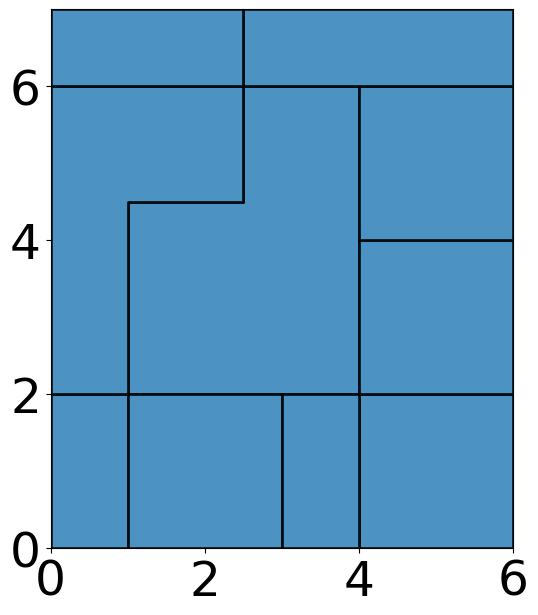

In [14]:
fig, ax = plt.subplots(figsize=(6,7))
ax.axis([0, 6, 0, 7])

patches = []

array = np.array(((0,0), (1,0), (1,2), (0,2)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((4,0), (6,0), (6,2), (4,2)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((1,2), (4,2), (4,6), (2.5,6), (2.5,4.5), (1,4.5)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((1,0),(3,0),(3,2),(1,2)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((3,0),(4,0),(4,2),(3,2)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((4,2),(6,2),(6,4),(4,4)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((4,4),(6,4),(6,6),(4,6)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((2.5,6),(6,6),(6,7),(2.5,7)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((0,2),(1,2),(1,4.5),(2.5,4.5),(2.5,6),(0,6)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

array = np.array(((0,6),(2.5,6),(2.5,7),(0,7)))
shape = mPolygon(array, lw = 2,edgecolor='black')
patches.append(shape)

colors = np.random.rand(len(patches))
p = PatchCollection(patches,cmap='Spectral',alpha=0.8,match_original = True)
#p.set_array(colors)
ax.add_collection(p)
ax.set_aspect('equal')  # ensures squares stay square
ax.tick_params(axis='both', which='major', labelsize=35)
plt.show()

In [8]:
# List of vertex arrays from your code
polygons_vertices = [
    ((0,0), (1,0), (1,2), (0,2)),
    ((4,0), (6,0), (6,2), (4,2)),
    ((1,2), (4,2), (4,6), (2.5,6), (2.5,4.5), (1,4.5)),
    ((1,0), (3,0), (3,2), (1,2)),
    ((3,0), (4,0), (4,2), (3,2)),
    ((4,2), (6,2), (6,4), (4,4)),
    ((4,4), (6,4), (6,6), (4,6)),
    ((2.5,6), (6,6), (6,7), (2.5,7)),
    ((0,2), (1,2), (1,4.5), (2.5,4.5), (2.5,6), (0,6)),
    ((0,6), (2.5,6), (2.5,7), (0,7))
]

# Convert to Shapely objects
poly_objs = [Polygon(v) for v in polygons_vertices]

In [9]:
def generate_unstructured_domain(poly_objs,dx):
    n = len(poly_objs)
    adj_prisms = {i: [] for i in range(n)}
    A_ij = {i: poly_objs[i].area*dx**2 for i in range(n)}
    
    # Initialize matrices for W and L (size n x n)
    W_ij = np.zeros((n, n))
    L_ij = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            # Check if polygons touch
            if poly_objs[i].touches(poly_objs[j]):
                # Calculate the intersection (the shared edge)
                intersection = poly_objs[i].intersection(poly_objs[j])
                
                # Only care if they share a line (length > 0), not just a corner point
                if intersection.length > 0:
                    adj_prisms[i].append(j)
                    adj_prisms[j].append(i)
                    
                    # Width = Length of the shared boundary
                    W_ij[i][j] = W_ij[j][i] = intersection.length*dx
                    
                    # Distance = distance between centroids
                    dist = poly_objs[i].centroid.distance(poly_objs[j].centroid)
                    L_ij[i][j] = L_ij[j][i] = dist*dx

    # Convert matrices to the dictionary format expected by the class
    W_dict = {i: list(row) for i, row in enumerate(W_ij)}
    L_dict = {i: list(row) for i, row in enumerate(L_ij)}
    
    return adj_prisms, A_ij, W_dict, L_dict

# Generate the domain
adj, areas, widths, lengths = generate_unstructured_domain(poly_objs,0.04)

In [10]:
n_layers = 5
n_prisms = 10
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04]


In [18]:
# Initialize the solver with the new grid
uns_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.full((n_prisms,n_layers),100/100/3600),        # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = np.full((n_prisms),10.1),
    rainfall_intensity = 0.1/100/86400,
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths
)

In [19]:
# Setup initial state
h_old = np.full(uns_grid_solver.total_cells, -10.0)
dt = 864 #s

# 3. Run simulation
for t in range(150):
    h_new = uns_grid_solver.solve_step(h_old, dt)
    h_old = h_new
    print(f"Step {t} completed.")

Step 0 completed.
Step 1 completed.
Step 2 completed.
Step 3 completed.
Step 4 completed.
Step 5 completed.
Step 6 completed.
Step 7 completed.
Step 8 completed.
Step 9 completed.
Step 10 completed.
Step 11 completed.
Step 12 completed.
Step 13 completed.
Step 14 completed.
Step 15 completed.
Step 16 completed.
Step 17 completed.
Step 18 completed.
Step 19 completed.
Step 20 completed.
Step 21 completed.
Step 22 completed.
Step 23 completed.
Step 24 completed.
Step 25 completed.
Step 26 completed.
Step 27 completed.
Step 28 completed.
Step 29 completed.
Step 30 completed.
Step 31 completed.
Step 32 completed.
Step 33 completed.
Step 34 completed.
Step 35 completed.
Step 36 completed.
Step 37 completed.
Step 38 completed.
Step 39 completed.
Step 40 completed.
Step 41 completed.
Step 42 completed.
Step 43 completed.
Step 44 completed.
Step 45 completed.
Step 46 completed.
Step 47 completed.
Step 48 completed.
Step 49 completed.
Step 50 completed.
Step 51 completed.
Step 52 completed.
Ste

In [20]:
h_start = np.full(uns_grid_solver.total_cells, -10.0)
run_mass_balance_check(uns_grid_solver, h_start, 864, 150)

Step     | Error (m3)      | Rel. Error (%) 
---------------------------------------------
0        | -2.612038e-19   | -2.484830e-14  
5        | 1.122972e-15    | 1.064879e-10   
10       | 1.970636e-16    | 1.862757e-11   
15       | 5.004578e-17    | 4.715633e-12   
20       | 1.600183e-17    | 1.503036e-12   
25       | 6.677690e-18    | 6.252555e-13   
30       | 2.991403e-18    | 2.792171e-13   
35       | 1.473520e-18    | 1.371081e-13   
40       | 8.229984e-19    | 7.633971e-14   
45       | 6.061580e-19    | 5.605132e-14   
50       | 6.061580e-19    | 5.587771e-14   
55       | 1.724771e-19    | 1.585043e-14   
60       | -4.436335e-20   | -4.064387e-15  
65       | 6.061580e-19    | 5.536327e-14   
70       | -4.780442e-19   | -4.352846e-14  
75       | -4.436335e-20   | -4.027197e-15  
80       | -2.612038e-19   | -2.363934e-14  
85       | 6.061580e-19    | 5.469191e-14   
90       | -4.436335e-20   | -3.990680e-15  
95       | 1.724771e-19    | 1.546833e-14   
100      

In [21]:
h_start = np.full(uns_grid_solver.total_cells, -10.0)
t2, err2, cum2 = run_simulation_with_diagnostics(uns_grid_solver, h_start, 864, 150)

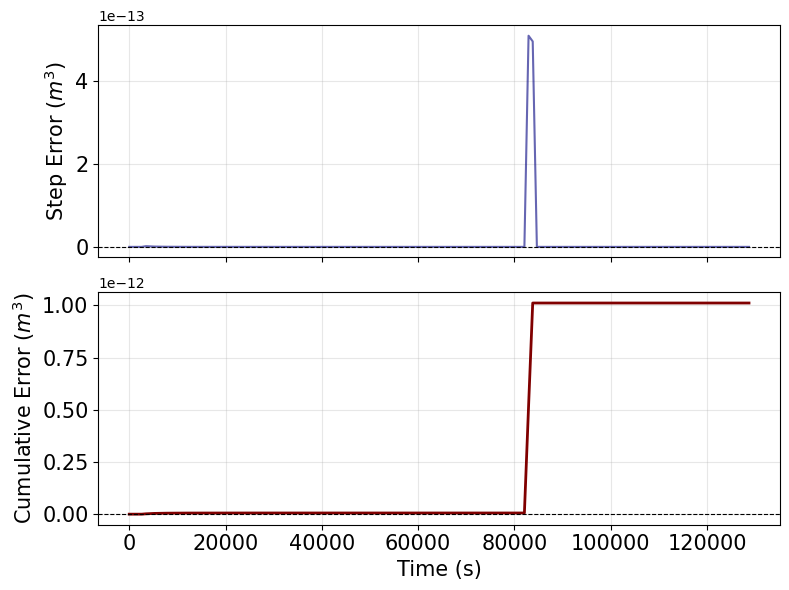

In [22]:
plot_mass_diagnostics(t2, err2, cum2, title="Unstructured Grid Experiment")

/opt/anaconda3/envs/env_pytorch/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


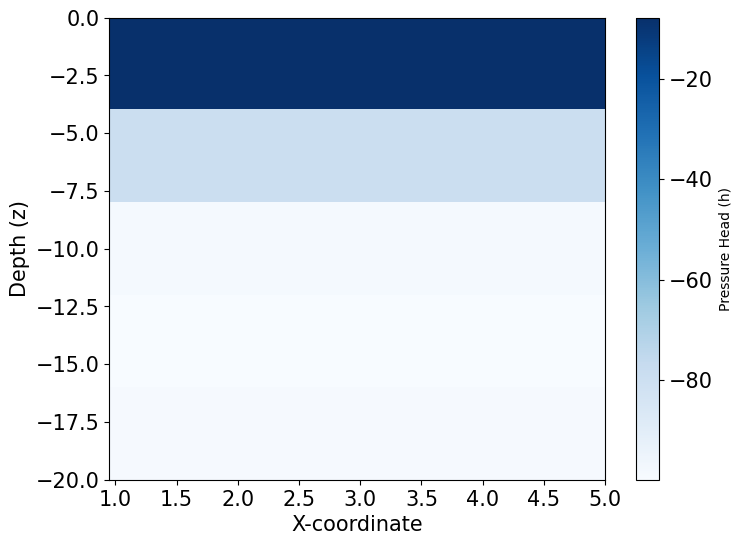

In [23]:
from shapely.geometry import LineString

def get_vertical_slice_unstructured(h_new, poly_objs, y_slice, solver):
    """
    h_new: 1D array of results
    poly_objs: list of shapely Polygons used to build the domain
    y_slice: the specific Y coordinate to cut through
    """
    # Create a horizontal line across the entire domain width (0 to 6)
    slice_line = LineString([(0, y_slice), (6, y_slice)])
    
    # Identify which polygons are hit by the slice line
    intersecting_indices = []
    x_offsets = [] # Where along the line the intersection happens
    
    for i, poly in enumerate(poly_objs):
        if poly.intersects(slice_line):
            intersecting_indices.append(i)
            # Use the centroid's X to order the prisms from left to right
            x_offsets.append(poly.centroid.x)
            
    # Sort indices based on X position so the plot goes left -> right
    sorted_zip = sorted(zip(x_offsets, intersecting_indices))
    sorted_indices = [idx for x, idx in sorted_zip]
    sorted_x = [x for x, idx in sorted_zip]

    # Extract data for these prisms across all layers
    # Resulting shape: (n_layers, n_intersecting_prisms)
    slice_data = np.zeros((solver.n_layers, len(sorted_indices)))
    
    for layer_k in range(solver.n_layers):
        for plot_col, prism_i in enumerate(sorted_indices):
            global_idx = layer_k * len(poly_objs) + prism_i
            slice_data[layer_k, plot_col] = h_new[global_idx]
            
    return slice_data, sorted_x

# --- Example Plotting ---
y_coord = 3 # The Y coordinate you want to "cut" through
data, x_ticks = get_vertical_slice_unstructured(h_new, poly_objs, y_coord, uns_grid_solver)

plt.figure(figsize=(8, 6))
plt.imshow(np.flipud(data)*10, aspect='auto', cmap='Blues', 
           extent=[min(x_ticks), max(x_ticks), -sum(uns_grid_solver.dz*100), 0])
cbar = plt.colorbar(label="Pressure Head (h)")
cbar.ax.tick_params(labelsize=15)
plt.xlabel(f"X-coordinate",fontsize=15)
plt.ylabel("Depth (z)",fontsize=15)
#plt.title(f"Vertical Slice Through Unstructured Grid")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

# Example 2D Regular Grid. Variable Ksat

In [24]:
# Generate parameters
adj, areas, widths, lengths = generate_regular_grid(7, 6)

In [25]:
n_layers = 5
n_prisms = 42
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04]


In [26]:
# Initialize the solver with the new grid
reg_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.tile([2e-5,2e-4,2e-3,2e-2,2e-1],(n_prisms,1)),        # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = np.full((n_prisms),10.1),
    rainfall_intensity = 0.1/100/86400,
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths
)

In [27]:
# Setup initial state
h_old = np.full(reg_grid_solver.total_cells, -10.0)
dt = 864 #s

# 3. Run simulation
for t in range(150):
    h_new = reg_grid_solver.solve_step(h_old, dt)
    h_old = h_new
    print(f"Step {t} completed.")

Step 0 completed.
Step 1 completed.
Step 2 completed.
Step 3 completed.
Step 4 completed.
Step 5 completed.
Step 6 completed.
Step 7 completed.
Step 8 completed.
Step 9 completed.
Step 10 completed.
Step 11 completed.
Step 12 completed.
Step 13 completed.
Step 14 completed.
Step 15 completed.
Step 16 completed.
Step 17 completed.
Step 18 completed.
Step 19 completed.
Step 20 completed.
Step 21 completed.
Step 22 completed.
Step 23 completed.
Step 24 completed.
Step 25 completed.
Step 26 completed.
Step 27 completed.
Step 28 completed.
Step 29 completed.
Step 30 completed.
Step 31 completed.
Step 32 completed.
Step 33 completed.
Step 34 completed.
Step 35 completed.
Step 36 completed.
Step 37 completed.
Step 38 completed.
Step 39 completed.
Step 40 completed.
Step 41 completed.
Step 42 completed.
Step 43 completed.
Step 44 completed.
Step 45 completed.
Step 46 completed.
Step 47 completed.
Step 48 completed.
Step 49 completed.
Step 50 completed.
Step 51 completed.
Step 52 completed.
Ste

In [28]:
h_start = np.full(reg_grid_solver.total_cells, -10.0)
run_mass_balance_check(reg_grid_solver, h_start, 864, 150)

Step     | Error (m3)      | Rel. Error (%) 
---------------------------------------------
0        | -6.955199e-19   | -6.616477e-14  
5        | 1.441539e-16    | 1.366966e-11   
10       | 3.323714e-16    | 3.141762e-11   
15       | 1.567711e-15    | 1.477198e-10   
20       | 3.529999e-17    | 3.315693e-12   
25       | 2.656684e-15    | 2.487546e-10   
30       | 6.893895e-18    | 6.434751e-13   
35       | 1.491699e-17    | 1.387997e-12   
40       | 5.373143e-17    | 4.984021e-12   
45       | 2.551762e-16    | 2.359610e-11   
50       | 1.420260e-15    | 1.309244e-10   
55       | 1.294087e-16    | 1.189250e-11   
60       | 2.226039e-15    | 2.039405e-10   
65       | 7.320083e-16    | 6.685778e-11   
70       | 1.191710e-15    | 1.085115e-10   
75       | 4.549149e-17    | 4.129607e-12   
80       | 5.925337e-15    | 5.362520e-10   
85       | 2.350505e-15    | 2.120794e-10   
90       | 1.443895e-15    | 1.298848e-10   
95       | 9.740022e-16    | 8.735181e-11   
100      

In [29]:
h_start = np.full(reg_grid_solver.total_cells, -10.0)
t1, err1, cum1 = run_simulation_with_diagnostics(reg_grid_solver, h_start, 864, 150)

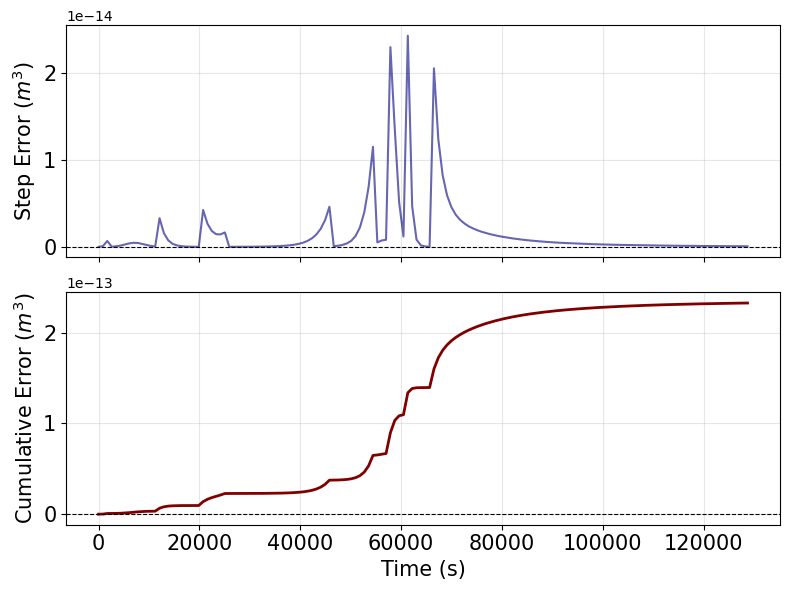

In [30]:
plot_mass_diagnostics(t1, err1, cum1, title="Regular Grid Experiment")

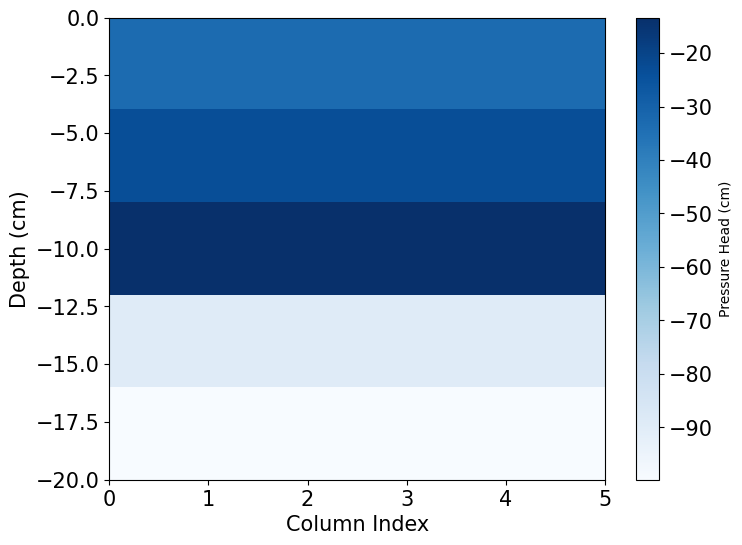

In [31]:
# Example usage:
plot_vertical_slice(h_new, 3, n_layers, dz,7,6)

# Example Unstructured Grid. Variable Ksat

In [32]:
# List of vertex arrays from your code
polygons_vertices = [
    ((0,0), (1,0), (1,2), (0,2)),
    ((4,0), (6,0), (6,2), (4,2)),
    ((1,2), (4,2), (4,6), (2.5,6), (2.5,4.5), (1,4.5)),
    ((1,0), (3,0), (3,2), (1,2)),
    ((3,0), (4,0), (4,2), (3,2)),
    ((4,2), (6,2), (6,4), (4,4)),
    ((4,4), (6,4), (6,6), (4,6)),
    ((2.5,6), (6,6), (6,7), (2.5,7)),
    ((0,2), (1,2), (1,4.5), (2.5,4.5), (2.5,6), (0,6)),
    ((0,6), (2.5,6), (2.5,7), (0,7))
]

# Convert to Shapely objects
poly_objs = [Polygon(v) for v in polygons_vertices]

In [33]:
# Generate the domain
adj, areas, widths, lengths = generate_unstructured_domain(poly_objs,0.04)

In [34]:
n_layers = 5
n_prisms = 10
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04]


In [35]:
uns_grid_solver.base_elevations

array([10.1, 10.1, 10.1, 10.1, 10.1, 10.1, 10.1, 10.1, 10.1, 10.1])

In [36]:
# Initialize the solver with the new grid
uns_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.tile([2e-5,2e-4,2e-3,2e-2,2e-1],(n_prisms,1)),        # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = np.full((n_prisms),10.1),
    rainfall_intensity = 0.1/100/86400,
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths
)

In [37]:
# Setup initial state
h_old = np.full(uns_grid_solver.total_cells, -10.0)
dt = 864 #s

# 3. Run simulation
for t in range(150):
    h_new = uns_grid_solver.solve_step(h_old, dt)
    h_old = h_new
    print(f"Step {t} completed.")

Step 0 completed.
Step 1 completed.
Step 2 completed.
Step 3 completed.
Step 4 completed.
Step 5 completed.
Step 6 completed.
Step 7 completed.
Step 8 completed.
Step 9 completed.
Step 10 completed.
Step 11 completed.
Step 12 completed.
Step 13 completed.
Step 14 completed.
Step 15 completed.
Step 16 completed.
Step 17 completed.
Step 18 completed.
Step 19 completed.
Step 20 completed.
Step 21 completed.
Step 22 completed.
Step 23 completed.
Step 24 completed.
Step 25 completed.
Step 26 completed.
Step 27 completed.
Step 28 completed.
Step 29 completed.
Step 30 completed.
Step 31 completed.
Step 32 completed.
Step 33 completed.
Step 34 completed.
Step 35 completed.
Step 36 completed.
Step 37 completed.
Step 38 completed.
Step 39 completed.
Step 40 completed.
Step 41 completed.
Step 42 completed.
Step 43 completed.
Step 44 completed.
Step 45 completed.
Step 46 completed.
Step 47 completed.
Step 48 completed.
Step 49 completed.
Step 50 completed.
Step 51 completed.
Step 52 completed.
Ste

In [38]:
h_start = np.full(uns_grid_solver.total_cells, -10.0)
run_mass_balance_check(uns_grid_solver, h_start, 864, 150)

Step     | Error (m3)      | Rel. Error (%) 
---------------------------------------------
0        | -4.436335e-20   | -4.220283e-15  
5        | 1.461061e-16    | 1.385478e-11   
10       | 3.390941e-16    | 3.205309e-11   
15       | 1.574651e-15    | 1.483737e-10   
20       | 3.660167e-17    | 3.437959e-12   
25       | 2.659720e-15    | 2.490389e-10   
30       | 4.942967e-18    | 4.613757e-13   
35       | 1.686919e-17    | 1.569645e-12   
40       | 5.893623e-17    | 5.466809e-12   
45       | 2.536589e-16    | 2.345580e-11   
50       | 1.420477e-15    | 1.309445e-10   
55       | 1.287589e-16    | 1.183278e-11   
60       | 2.223437e-15    | 2.037022e-10   
65       | 7.298405e-16    | 6.665978e-11   
70       | 1.196264e-15    | 1.089262e-10   
75       | 4.809421e-17    | 4.365875e-12   
80       | 5.923819e-15    | 5.361147e-10   
85       | 2.356577e-15    | 2.126273e-10   
90       | 1.445197e-15    | 1.300019e-10   
95       | 9.731355e-16    | 8.727408e-11   
100      

In [39]:
h_start = np.full(uns_grid_solver.total_cells, -10.0)
t2, err2, cum2 = run_simulation_with_diagnostics(uns_grid_solver, h_start, 864, 150)

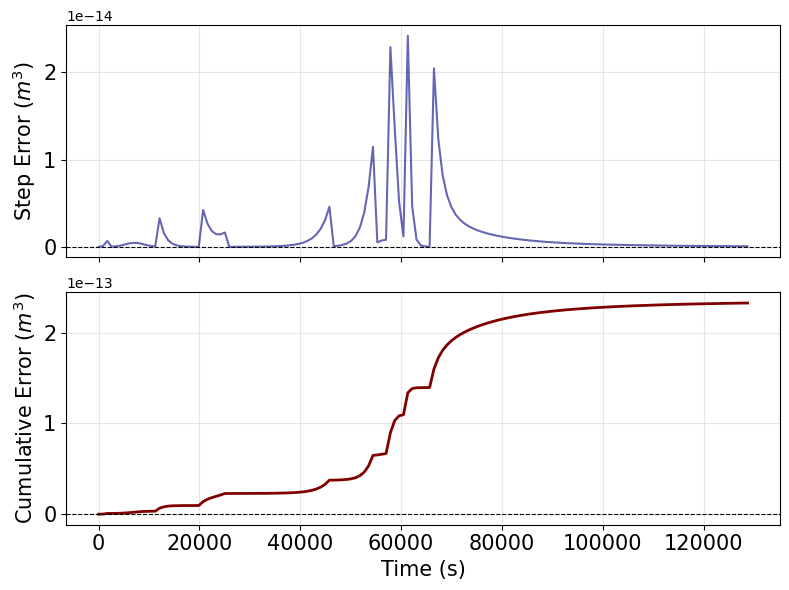

In [40]:
plot_mass_diagnostics(t2, err2, cum2, title="Unstructured Grid Experiment")

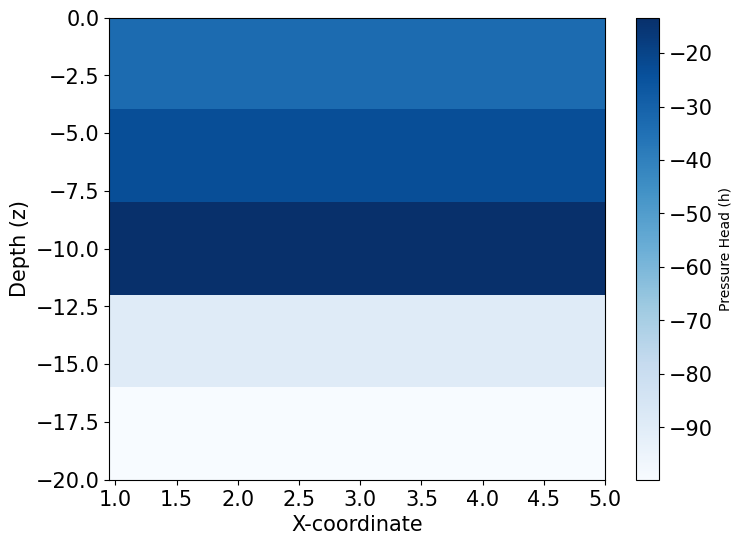

In [41]:
# --- Example Plotting ---
y_coord = 3 # The Y coordinate you want to "cut" through
data, x_ticks = get_vertical_slice_unstructured(h_new, poly_objs, y_coord, uns_grid_solver)

plt.figure(figsize=(8, 6))
plt.imshow(np.flipud(data)*10, aspect='auto', cmap='Blues', 
           extent=[min(x_ticks), max(x_ticks), -sum(uns_grid_solver.dz*100), 0])
cbar = plt.colorbar(label="Pressure Head (h)")
cbar.ax.tick_params(labelsize=15)
plt.xlabel(f"X-coordinate",fontsize=15)
plt.ylabel("Depth (z)",fontsize=15)
#plt.title(f"Vertical Slice Through Unstructured Grid")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

# Example 2D Regular Grid. Variable Ksat. Variable Elevation

In [42]:
# Generate parameters
adj, areas, widths, lengths = generate_regular_grid(7, 6)

In [43]:
n_layers = 5
n_prisms = 42
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04]


In [44]:
np.tile([10.0, 10.2, 10.5, 10.3, 10.1, 10.0],(7,1)).flatten()

array([10. , 10.2, 10.5, 10.3, 10.1, 10. , 10. , 10.2, 10.5, 10.3, 10.1,
       10. , 10. , 10.2, 10.5, 10.3, 10.1, 10. , 10. , 10.2, 10.5, 10.3,
       10.1, 10. , 10. , 10.2, 10.5, 10.3, 10.1, 10. , 10. , 10.2, 10.5,
       10.3, 10.1, 10. , 10. , 10.2, 10.5, 10.3, 10.1, 10. ])

In [45]:
# Initialize the solver with the new grid
reg_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.tile([2e-5,2e-4,2e-3,2e-2,2e-1],(n_prisms,1)),        # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = np.tile([10.0, 10.2, 10.5, 10.3, 10.1, 10.0],(7,1)).flatten(),
    rainfall_intensity = 0.1/100/86400,
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths
)

In [46]:
# Setup initial state
h_old = np.full(reg_grid_solver.total_cells, -10.0)
dt = 864 #s

# 3. Run simulation
for t in range(150):
    h_new = reg_grid_solver.solve_step(h_old, dt)
    h_old = h_new
    print(f"Step {t} completed.")

Step 0 completed.
Step 1 completed.
Step 2 completed.
Step 3 completed.
Step 4 completed.
Step 5 completed.
Step 6 completed.
Step 7 completed.
Step 8 completed.
Step 9 completed.
Step 10 completed.
Step 11 completed.
Step 12 completed.
Step 13 completed.
Step 14 completed.
Step 15 completed.
Step 16 completed.
Step 17 completed.
Step 18 completed.
Step 19 completed.
Step 20 completed.
Step 21 completed.
Step 22 completed.
Step 23 completed.
Step 24 completed.
Step 25 completed.
Step 26 completed.
Step 27 completed.
Step 28 completed.
Step 29 completed.
Step 30 completed.
Step 31 completed.
Step 32 completed.
Step 33 completed.
Step 34 completed.
Step 35 completed.
Step 36 completed.
Step 37 completed.
Step 38 completed.
Step 39 completed.
Step 40 completed.
Step 41 completed.
Step 42 completed.
Step 43 completed.
Step 44 completed.
Step 45 completed.
Step 46 completed.
Step 47 completed.
Step 48 completed.
Step 49 completed.
Step 50 completed.
Step 51 completed.
Step 52 completed.
Ste

In [47]:
h_start = np.full(reg_grid_solver.total_cells, -10.0)
run_mass_balance_check(reg_grid_solver, h_start, 864, 150)

Step     | Error (m3)      | Rel. Error (%) 
---------------------------------------------
0        | -6.955199e-19   | -6.616477e-14  
5        | 1.441539e-16    | 1.366966e-11   
10       | 3.323714e-16    | 3.141762e-11   
15       | 1.567711e-15    | 1.477198e-10   
20       | 3.529999e-17    | 3.315693e-12   
25       | 2.656684e-15    | 2.487546e-10   
30       | 6.893895e-18    | 6.434751e-13   
35       | 1.491699e-17    | 1.387997e-12   
40       | 5.373143e-17    | 4.984021e-12   
45       | 2.551762e-16    | 2.359610e-11   
50       | 1.420260e-15    | 1.309244e-10   
55       | 1.294087e-16    | 1.189250e-11   
60       | 2.226039e-15    | 2.039405e-10   
65       | 7.320083e-16    | 6.685778e-11   
70       | 1.191710e-15    | 1.085115e-10   
75       | 4.549149e-17    | 4.129607e-12   
80       | 5.925337e-15    | 5.362520e-10   
85       | 2.350505e-15    | 2.120794e-10   
90       | 1.443895e-15    | 1.298848e-10   
95       | 9.740022e-16    | 8.735181e-11   
100      

In [48]:
h_start = np.full(reg_grid_solver.total_cells, -10.0)
t1, err1, cum1 = run_simulation_with_diagnostics(reg_grid_solver, h_start, 864, 150)

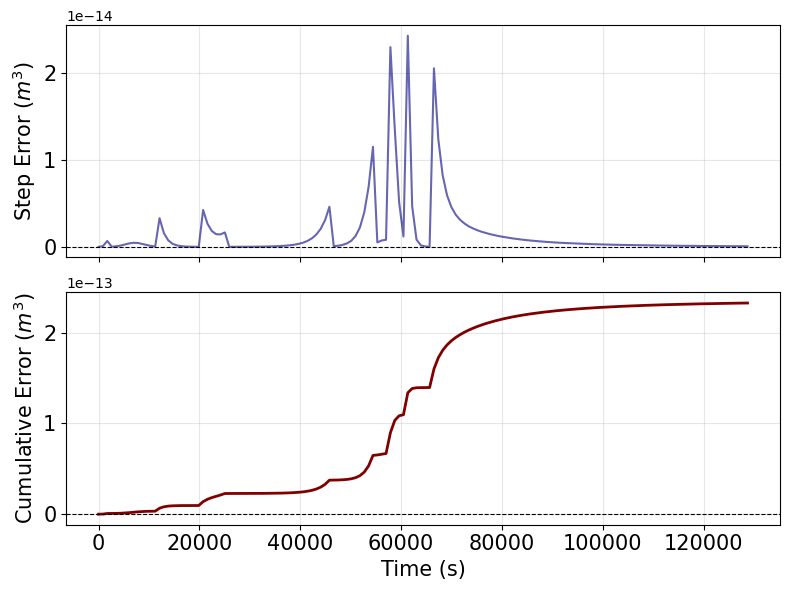

In [49]:
plot_mass_diagnostics(t1, err1, cum1, title="Regular Grid Experiment")

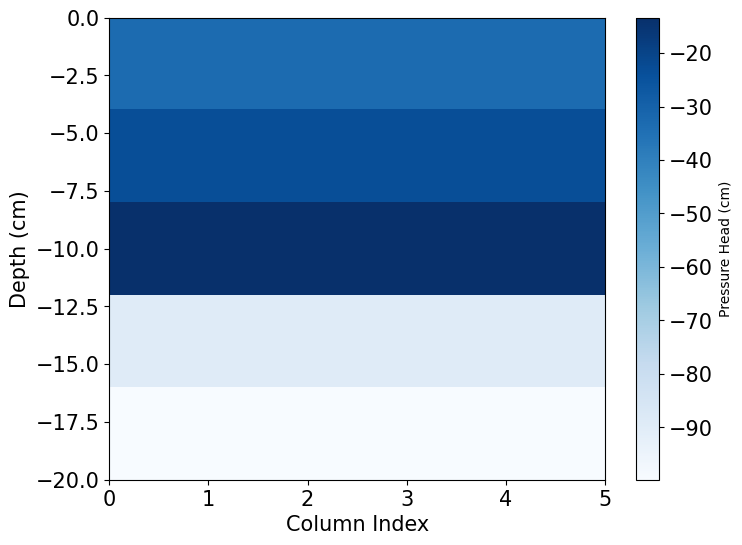

In [50]:
# Example usage:
plot_vertical_slice(h_new, 3, n_layers, dz,7,6)

# Example Unstructured Grid. Variable Ksat. Variable Elevation

In [51]:
# List of vertex arrays from your code
polygons_vertices = [
    ((0,0), (1,0), (1,2), (0,2)),
    ((4,0), (6,0), (6,2), (4,2)),
    ((1,2), (4,2), (4,6), (2.5,6), (2.5,4.5), (1,4.5)),
    ((1,0), (3,0), (3,2), (1,2)),
    ((3,0), (4,0), (4,2), (3,2)),
    ((4,2), (6,2), (6,4), (4,4)),
    ((4,4), (6,4), (6,6), (4,6)),
    ((2.5,6), (6,6), (6,7), (2.5,7)),
    ((0,2), (1,2), (1,4.5), (2.5,4.5), (2.5,6), (0,6)),
    ((0,6), (2.5,6), (2.5,7), (0,7))
]

# Convert to Shapely objects
poly_objs = [Polygon(v) for v in polygons_vertices]

In [52]:
# Generate the domain
adj, areas, widths, lengths = generate_unstructured_domain(poly_objs,0.04)

In [53]:
n_layers = 5
n_prisms = 10
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04]


In [54]:
# Initialize the solver with the new grid
uns_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.tile([2e-5,2e-4,2e-3,2e-2,2e-1],(n_prisms,1)),        # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = [10.0,10.0,10.5,10.2,10.5,10.0,10.0,10.3,10.0,10.2],
    rainfall_intensity = 0.1/100/86400,
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths
)

In [55]:
# Setup initial state
h_old = np.full(uns_grid_solver.total_cells, -10.0)
dt = 864 #s

# 3. Run simulation
for t in range(150):
    h_new = uns_grid_solver.solve_step(h_old, dt)
    h_old = h_new
    print(f"Step {t} completed.")

Step 0 completed.
Step 1 completed.
Step 2 completed.
Step 3 completed.
Step 4 completed.
Step 5 completed.
Step 6 completed.
Step 7 completed.
Step 8 completed.
Step 9 completed.
Step 10 completed.
Step 11 completed.
Step 12 completed.
Step 13 completed.
Step 14 completed.
Step 15 completed.
Step 16 completed.
Step 17 completed.
Step 18 completed.
Step 19 completed.
Step 20 completed.
Step 21 completed.
Step 22 completed.
Step 23 completed.
Step 24 completed.
Step 25 completed.
Step 26 completed.
Step 27 completed.
Step 28 completed.
Step 29 completed.
Step 30 completed.
Step 31 completed.
Step 32 completed.
Step 33 completed.
Step 34 completed.
Step 35 completed.
Step 36 completed.
Step 37 completed.
Step 38 completed.
Step 39 completed.
Step 40 completed.
Step 41 completed.
Step 42 completed.
Step 43 completed.
Step 44 completed.
Step 45 completed.
Step 46 completed.
Step 47 completed.
Step 48 completed.
Step 49 completed.
Step 50 completed.
Step 51 completed.
Step 52 completed.
Ste

In [56]:
h_start = np.full(uns_grid_solver.total_cells, -10.0)
run_mass_balance_check(uns_grid_solver, h_start, 864, 150)

Step     | Error (m3)      | Rel. Error (%) 
---------------------------------------------
0        | -4.436335e-20   | -4.220283e-15  
5        | 1.461061e-16    | 1.385478e-11   
10       | 3.390941e-16    | 3.205309e-11   
15       | 1.574651e-15    | 1.483737e-10   
20       | 3.660167e-17    | 3.437959e-12   
25       | 2.659720e-15    | 2.490389e-10   
30       | 4.942967e-18    | 4.613757e-13   
35       | 1.686919e-17    | 1.569645e-12   
40       | 5.893623e-17    | 5.466809e-12   
45       | 2.536589e-16    | 2.345580e-11   
50       | 1.420477e-15    | 1.309445e-10   
55       | 1.287589e-16    | 1.183278e-11   
60       | 2.223437e-15    | 2.037022e-10   
65       | 7.298405e-16    | 6.665978e-11   
70       | 1.196264e-15    | 1.089262e-10   
75       | 4.809421e-17    | 4.365875e-12   
80       | 5.923819e-15    | 5.361147e-10   
85       | 2.356577e-15    | 2.126273e-10   
90       | 1.445197e-15    | 1.300019e-10   
95       | 9.731355e-16    | 8.727408e-11   
100      

In [57]:
h_start = np.full(uns_grid_solver.total_cells, -10.0)
t2, err2, cum2 = run_simulation_with_diagnostics(uns_grid_solver, h_start, 864, 150)

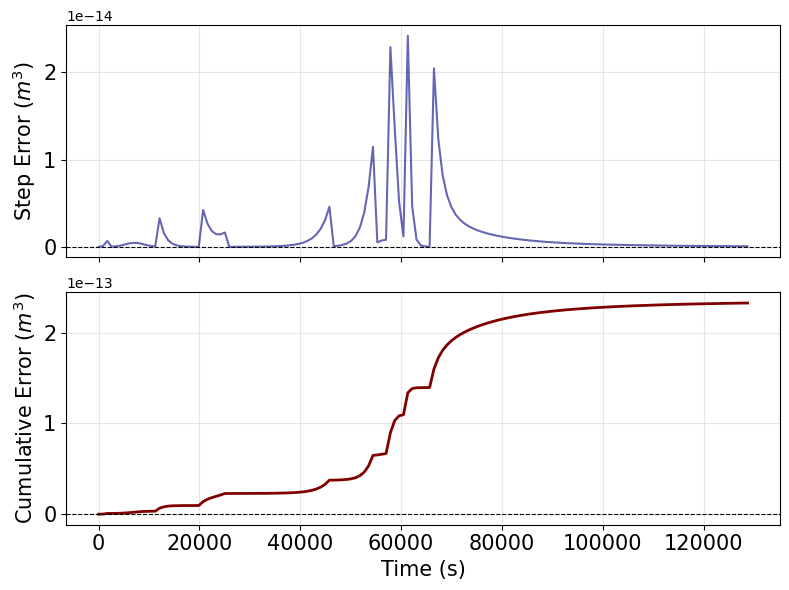

In [58]:
plot_mass_diagnostics(t2, err2, cum2, title="Unstructured Grid Experiment")

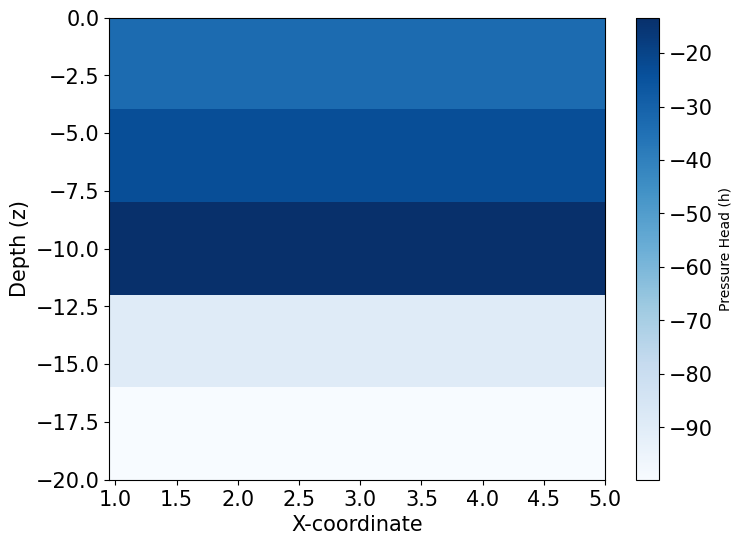

In [59]:
# --- Example Plotting ---
y_coord = 3 # The Y coordinate you want to "cut" through
data, x_ticks = get_vertical_slice_unstructured(h_new, poly_objs, y_coord, uns_grid_solver)

plt.figure(figsize=(8, 6))
plt.imshow(np.flipud(data)*10, aspect='auto', cmap='Blues', 
           extent=[min(x_ticks), max(x_ticks), -sum(uns_grid_solver.dz*100), 0])
cbar = plt.colorbar(label="Pressure Head (h)")
cbar.ax.tick_params(labelsize=15)
plt.xlabel(f"X-coordinate",fontsize=15)
plt.ylabel("Depth (z)",fontsize=15)
#plt.title(f"Vertical Slice Through Unstructured Grid")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

# Example Regular Grid. Variable Infiltration. Variable Elevation

In [11]:
# Helper utilities: build rainfall_prisms for regular/unstructured grids
# and print lateral-flow diagnostics each timestep.

def build_regular_column_rainfall_prisms(rows, cols, target_cols):
    if isinstance(target_cols, int):
        target_cols = [target_cols]

    if target_cols is None or len(target_cols) == 0:
        raise ValueError("target_cols must contain at least one column index")

    prism_ids = set()
    for col in target_cols:
        if col < 0 or col >= cols:
            raise ValueError(f"Each column index must be in [0, {cols-1}]. Invalid value: {col}")
        for r in range(rows):
            prism_ids.add(r * cols + col)

    return sorted(prism_ids)


def build_unstructured_column_rainfall_prisms(poly_objs, x_target=None, tol=None):
    x_centroids = np.array([poly.centroid.x for poly in poly_objs], dtype=float)

    if x_target is None:
        x_target = float(np.median(x_centroids))

    if tol is None:
        unique_x = np.unique(np.sort(x_centroids))
        if len(unique_x) > 1:
            tol = 0.5 * np.min(np.diff(unique_x))
        else:
            tol = 1e-9

    prism_ids = np.where(np.abs(x_centroids - x_target) <= tol)[0].tolist()

    if len(prism_ids) == 0:
        nearest = int(np.argmin(np.abs(x_centroids - x_target)))
        prism_ids = [nearest]

    return prism_ids


def run_with_lateral_flow_check(solver, h_init, dt, steps, print_every=1):
    h_current = h_init.copy()

    print(f"{'Step':<8} | {'Lateral Exchange (m3/s)':<24}")
    print("-" * 40)

    for t in range(steps):
        h_next = solver.solve_step(h_current, dt)
        lateral_exchange = solver.get_total_lateral_exchange(h_next)

        if t % print_every == 0:
            print(f"{t:<8} | {lateral_exchange:<24.6e}")

        h_current = h_next

    print("-" * 40)
    return h_current


# -------------------------
# Example usage (regular):
# rows, cols = 7, 6
# rain_ids = build_regular_column_rainfall_prisms(rows, cols, target_cols=[1, 3, 5])
# reg_grid_solver = RichardsSolver(..., rainfall_intensity=0.1/100/86400, rainfall_prisms=rain_ids)
# h0 = np.full(reg_grid_solver.total_cells, -10.0)
# h_end = run_with_lateral_flow_check(reg_grid_solver, h0, dt=864, steps=20)
# -------------------------
# Example usage (unstructured):
# x_target = 3.0
# rain_ids = build_unstructured_column_rainfall_prisms(poly_objs, x_target=x_target, tol=0.6)
# uns_grid_solver = RichardsSolver(..., rainfall_intensity=0.1/100/86400, rainfall_prisms=rain_ids)
# h0 = np.full(uns_grid_solver.total_cells, -10.0)
# h_end = run_with_lateral_flow_check(uns_grid_solver, h0, dt=864, steps=20)


In [12]:
# Example usage (regular):
rows, cols = 7, 6
rain_ids = [10, 4, 5, 11]
adj, areas, widths, lengths = generate_regular_grid(7, 6)

In [13]:
n_layers = 5
n_prisms = 42
dz = np.full(n_layers,0.04)

In [14]:
# Initialize the solver with the new grid
reg_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.tile([2e-5,2e-4,2e-3,2e-2,2e-1],(n_prisms,1)),        # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = np.tile([10.0, 10.2, 10.5, 10.3, 10.1, 10.0],(7,1)).flatten(),
    rainfall_intensity = 0.1/100/86400,
    rainfall_prisms=rain_ids,
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths
)

In [106]:
h0 = np.full(reg_grid_solver.total_cells, -10.0)
h_end = run_with_lateral_flow_check(reg_grid_solver, h0, dt=864, steps=150)

Step     | Lateral Exchange (m3/s) 
----------------------------------------
0        | 3.408197e-11            
1        | 6.384327e-11            
2        | 8.895027e-11            
3        | 1.099193e-10            
4        | 1.274789e-10            
5        | 1.423274e-10            
6        | 1.550562e-10            
7        | 1.661406e-10            
8        | 1.759509e-10            
9        | 1.847707e-10            
10       | 1.928135e-10            
11       | 2.002382e-10            
12       | 2.071612e-10            
13       | 2.136673e-10            
14       | 2.198171e-10            
15       | 2.256542e-10            
16       | 2.312095e-10            
17       | 2.365052e-10            
18       | 2.415577e-10            
19       | 2.463792e-10            
20       | 2.509793e-10            
21       | 2.553661e-10            
22       | 2.595468e-10            
23       | 2.635280e-10            
24       | 2.673161e-10            
25       | 2.709174e-10

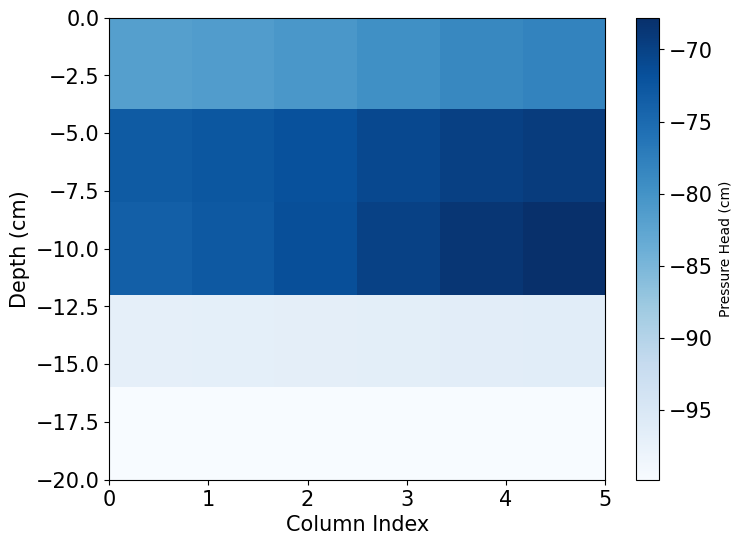

In [107]:
# Example usage:
plot_vertical_slice(h_end, 3, n_layers, dz,7,6)

In [108]:
h_start = np.full(reg_grid_solver.total_cells, -10.0)
t1, err1, cum1 = run_simulation_with_diagnostics(reg_grid_solver, h_start, 864, 150)

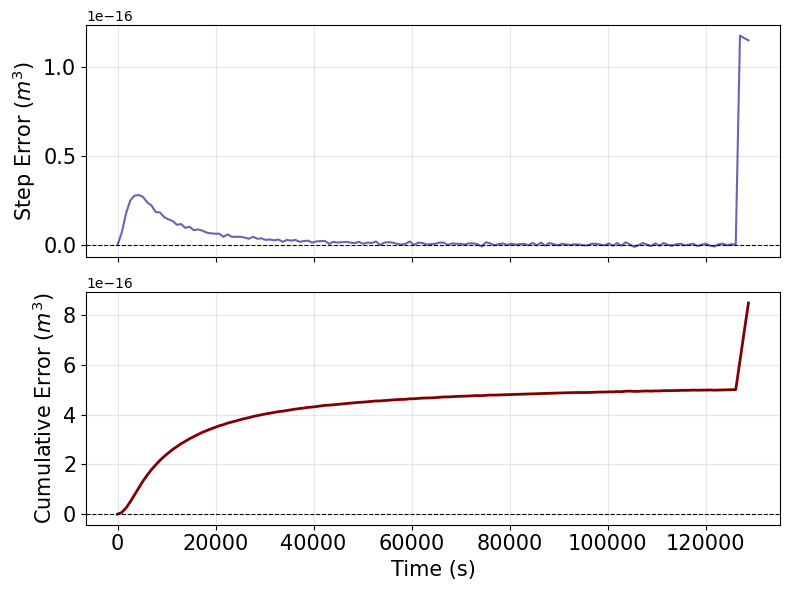

In [109]:
plot_mass_diagnostics(t1, err1, cum1, title="Regular Grid Experiment")

# Example Unstructured Grid. Variable Infiltration. Variable Ksat

In [15]:
# Generate the domain
adj, areas, widths, lengths = generate_unstructured_domain(poly_objs,0.04)

In [16]:
n_layers = 5
n_prisms = 10
dz = np.full(n_layers,0.04)
print(dz)

[0.04 0.04 0.04 0.04 0.04]


In [17]:
# Example usage (unstructured):
rain_ids = [1]
uns_grid_solver = RichardsSolver(
    # --- Van Genuchten Parameters ---
    alpha = 0.067*100,  # 1/m
    n_vg = 2,
    theta_r = np.full((n_prisms,n_layers),0.075),
    theta_s = np.full((n_prisms,n_layers),0.287),
    Ks = np.tile([2e-5,2e-4,2e-3,2e-2,2e-1],(n_prisms,1)), # Saturated hydraulic conductivity [cm/h] --> [m/s]
    # --- Domain Definition ---
    dz = dz,
    base_elevations = [10.0,10.0,10.5,10.2,10.5,10.0,10.0,10.3,10.0,10.2],
    adj_prisms=adj,
    A_ij=areas,
    W_ij=widths,
    L_ij=lengths, 
    rainfall_intensity=0.1/100/86400, 
    rainfall_prisms=rain_ids)


In [113]:
h0 = np.full(uns_grid_solver.total_cells, -10.0)
h_end = run_with_lateral_flow_check(uns_grid_solver, h0, dt=864, steps=150)

Step     | Lateral Exchange (m3/s) 
----------------------------------------
0        | 1.847938e-11            
1        | 3.407819e-11            
2        | 4.704797e-11            
3        | 5.781917e-11            
4        | 6.680392e-11            
5        | 7.436195e-11            
6        | 8.079563e-11            
7        | 8.635222e-11            
8        | 9.122916e-11            
9        | 9.558060e-11            
10       | 9.952438e-11            
11       | 1.031487e-10            
12       | 1.065183e-10            
13       | 1.096796e-10            
14       | 1.126655e-10            
15       | 1.154986e-10            
16       | 1.181944e-10            
17       | 1.207636e-10            
18       | 1.232134e-10            
19       | 1.255489e-10            
20       | 1.277739e-10            
21       | 1.298917e-10            
22       | 1.319051e-10            
23       | 1.338168e-10            
24       | 1.356298e-10            
25       | 1.373468e-10

In [114]:
h_start = np.full(uns_grid_solver.total_cells, -10.0)
t2, err2, cum2 = run_simulation_with_diagnostics(uns_grid_solver, h_start, 864, 150)

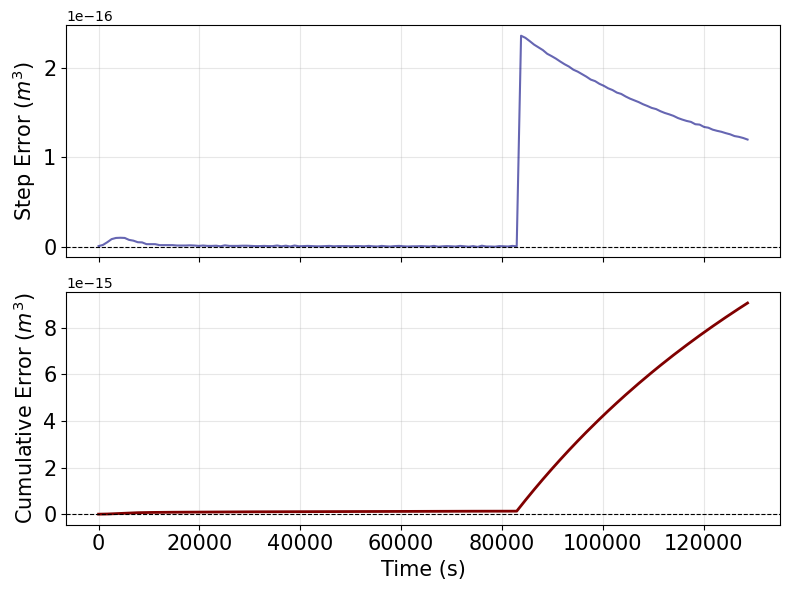

In [115]:
plot_mass_diagnostics(t2, err2, cum2, title="Unstructured Grid Experiment")

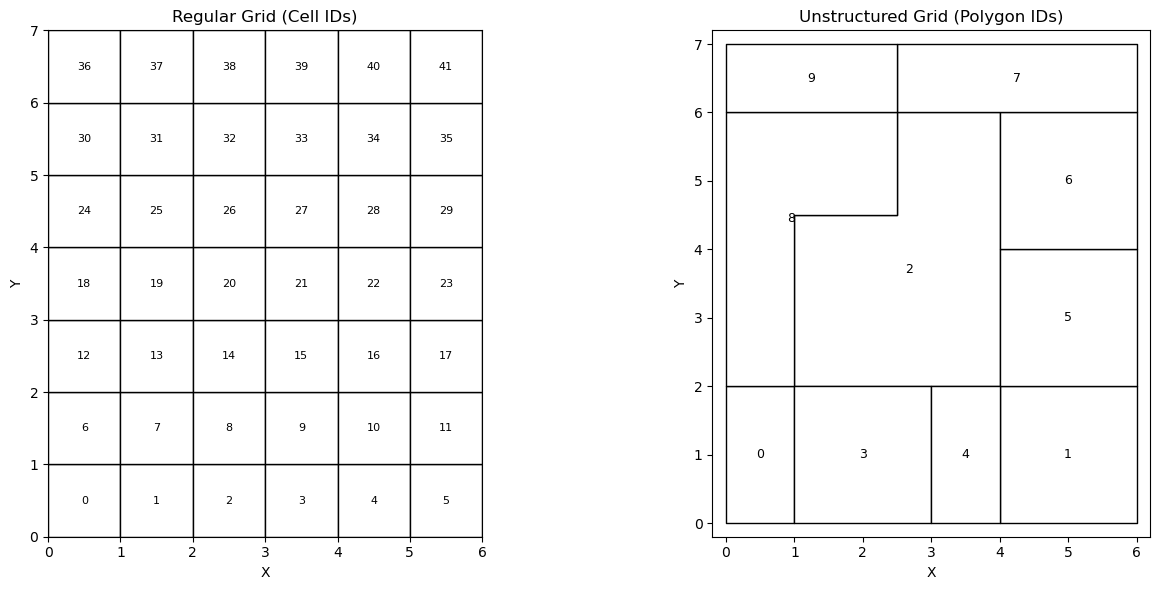

In [100]:
# Plot regular and unstructured geometries with prism/cell IDs overlaid
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as mPolygon
from matplotlib.collections import PatchCollection

# --- Regular grid settings (uses notebook vars if available) ---
rows_reg = int(rows) if 'rows' in globals() else 7
cols_reg = int(cols) if 'cols' in globals() else 6

# --- Unstructured polygons (uses notebook vars if available) ---
if 'poly_objs' in globals() and len(poly_objs) > 0:
    poly_list = poly_objs
elif 'polygons_vertices' in globals() and len(polygons_vertices) > 0:
    poly_list = [Polygon(v) for v in polygons_vertices]
else:
    raise ValueError("No unstructured geometry found. Define poly_objs or polygons_vertices first.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------
# 1) Regular grid + IDs
# ------------------------------
regular_patches = []
for r in range(rows_reg):
    for c in range(cols_reg):
        i = r * cols_reg + c
        square = [(c, r), (c + 1, r), (c + 1, r + 1), (c, r + 1)]
        regular_patches.append(mPolygon(square, closed=True))
        ax1.text(c + 0.5, r + 0.5, str(i), ha='center', va='center', fontsize=8, color='black')

pc_reg = PatchCollection(regular_patches, facecolor='white', edgecolor='black', linewidth=1)
ax1.add_collection(pc_reg)
ax1.set_xlim(0, cols_reg)
ax1.set_ylim(0, rows_reg)
ax1.set_aspect('equal')
ax1.set_title('Regular Grid (Cell IDs)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# ------------------------------
# 2) Unstructured grid + IDs
# ------------------------------
unstructured_patches = []
all_x = []
all_y = []

for i, poly in enumerate(poly_list):
    coords = list(poly.exterior.coords)
    unstructured_patches.append(mPolygon(coords, closed=True))

    centroid = poly.centroid
    ax2.text(centroid.x, centroid.y, str(i), ha='center', va='center', fontsize=9, color='black')

    xy = np.array(coords)
    all_x.extend(xy[:, 0])
    all_y.extend(xy[:, 1])

pc_uns = PatchCollection(unstructured_patches, facecolor='white', edgecolor='black', linewidth=1)
ax2.add_collection(pc_uns)
ax2.set_aspect('equal')
ax2.set_title('Unstructured Grid (Polygon IDs)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

pad = 0.2
ax2.set_xlim(min(all_x) - pad, max(all_x) + pad)
ax2.set_ylim(min(all_y) - pad, max(all_y) + pad)

plt.tight_layout()
plt.show()

# Comparison Regular and Unstructured Implicit Solver

In [19]:
# Define both experiments from scratch with identical physics parameters
# (different only in grid structure)

# --- Shared physical parameters ---
alpha_shared = 0.067 * 100
n_vg_shared = 2
theta_r_shared = 0.075
theta_s_shared = 0.287
Ks_shared = 100 / 100 / 3600
S_s_shared = 1e-10
rainfall_intensity_shared = 0.1 / 100 / 86400
n_layers_shared = 5
dz_shared = np.full(n_layers_shared, 0.04)

# --- Regular grid experiment ---
rows_reg, cols_reg = 7, 6
adj_reg, areas_reg, widths_reg, lengths_reg = generate_regular_grid(rows_reg, cols_reg)
n_prisms_reg = rows_reg * cols_reg
rain_ids_reg = [10, 4, 5, 11]

reg_grid_solver = RichardsSolver(
    alpha=alpha_shared,
    n_vg=n_vg_shared,
    theta_r=np.full((n_prisms_reg, n_layers_shared), theta_r_shared),
    theta_s=np.full((n_prisms_reg, n_layers_shared), theta_s_shared),
    Ks=np.full((n_prisms_reg, n_layers_shared), Ks_shared),
    S_s=S_s_shared,
    dz=dz_shared,
    base_elevations=np.full(n_prisms_reg, 10.1),
    rainfall_intensity=rainfall_intensity_shared,
    rainfall_prisms=rain_ids_reg,
    adj_prisms=adj_reg,
    A_ij=areas_reg,
    W_ij=widths_reg,
    L_ij=lengths_reg,
)

# --- Unstructured grid experiment ---
adj_uns, areas_uns, widths_uns, lengths_uns = generate_unstructured_domain(poly_objs, 0.04)
n_prisms_uns = len(areas_uns)
rain_ids_uns = [1]

uns_grid_solver = RichardsSolver(
    alpha=alpha_shared,
    n_vg=n_vg_shared,
    theta_r=np.full((n_prisms_uns, n_layers_shared), theta_r_shared),
    theta_s=np.full((n_prisms_uns, n_layers_shared), theta_s_shared),
    Ks=np.full((n_prisms_uns, n_layers_shared), Ks_shared),
    S_s=S_s_shared,
    dz=dz_shared,
    base_elevations=np.full(n_prisms_uns, 10.1),
    rainfall_intensity=rainfall_intensity_shared,
    rainfall_prisms=rain_ids_uns,
    adj_prisms=adj_uns,
    A_ij=areas_uns,
    W_ij=widths_uns,
    L_ij=lengths_uns,
)

print(f"Regular solver: n_prisms={n_prisms_reg}, rain_ids={rain_ids_reg}")
print(f"Unstructured solver: n_prisms={n_prisms_uns}, rain_ids={rain_ids_uns}")

Regular solver: n_prisms=42, rain_ids=[10, 4, 5, 11]
Unstructured solver: n_prisms=10, rain_ids=[1]


In [20]:
# Run both experiments and compare integrated metrics side-by-side

if 'reg_grid_solver' not in globals() or 'uns_grid_solver' not in globals():
    raise ValueError("reg_grid_solver and uns_grid_solver must be defined before running this cell.")


def run_experiment_metrics(solver, dt, steps, h0_value=-10.0):
    h = np.full(solver.total_cells, h0_value)

    s0 = solver.calculate_storage(h)
    cumulative_inflow = 0.0
    cumulative_lateral_exchange = 0.0

    for _ in range(steps):
        h = solver.solve_step(h, dt)

        q_in = solver.get_boundary_flux_with_rain(h)  # m3/s
        cumulative_inflow += q_in * dt                # m3

        q_lat = solver.get_total_lateral_exchange(h)  # m3/s
        cumulative_lateral_exchange += q_lat * dt     # m3

    s_end = solver.calculate_storage(h)
    storage_change = s_end - s0
    mass_error = storage_change - cumulative_inflow
    rel_mass_error_pct = 100.0 * mass_error / (abs(cumulative_inflow) + 1e-30)

    return {
        "storage_initial_m3": s0,
        "storage_final_m3": s_end,
        "storage_change_m3": storage_change,
        "cumulative_inflow_m3": cumulative_inflow,
        "mass_error_m3": mass_error,
        "rel_mass_error_pct": rel_mass_error_pct,
        "cumulative_lateral_exchange_m3": cumulative_lateral_exchange,
    }


def relative_difference_pct(a, b):
    denom = max(abs(a), abs(b), 1e-30)
    return 100.0 * abs(a - b) / denom


# Shared settings for fair comparison
dt_compare = 864
steps_compare = 150

reg_metrics = run_experiment_metrics(reg_grid_solver, dt_compare, steps_compare)
uns_metrics = run_experiment_metrics(uns_grid_solver, dt_compare, steps_compare)

metric_keys = [
    "storage_initial_m3",
    "storage_final_m3",
    "storage_change_m3",
    "cumulative_inflow_m3",
    "mass_error_m3",
    "rel_mass_error_pct",
    "cumulative_lateral_exchange_m3",
]

print(f"Comparison settings: dt={dt_compare}s, steps={steps_compare}")
print("=" * 102)
print(f"{'Metric':<34} | {'Regular':>20} | {'Unstructured':>20} | {'RelDiff %':>12}")
print("-" * 102)

for key in metric_keys:
    reg_val = reg_metrics[key]
    uns_val = uns_metrics[key]
    rel_diff = relative_difference_pct(reg_val, uns_val)
    print(f"{key:<34} | {reg_val:>20.6e} | {uns_val:>20.6e} | {rel_diff:>12.4f}")

print("=" * 102)

Comparison settings: dt=864s, steps=150
Metric                             |              Regular |         Unstructured |    RelDiff %
------------------------------------------------------------------------------------------------------
storage_initial_m3                 |         1.050522e-03 |         1.050522e-03 |       0.0000
storage_final_m3                   |         1.060122e-03 |         1.060122e-03 |       0.0000
storage_change_m3                  |         9.600001e-06 |         9.600001e-06 |       0.0000
cumulative_inflow_m3               |         9.600000e-06 |         9.600000e-06 |       0.0000
mass_error_m3                      |         9.233420e-13 |         1.163162e-12 |      20.6179
rel_mass_error_pct                 |         9.618145e-06 |         1.211627e-05 |      20.6179
cumulative_lateral_exchange_m3     |         2.999240e-07 |         1.004220e-07 |      66.5175
